# PM2.5 Forecasting Using SARIMA (Per City)

## Objective
This notebook applies **SARIMA** to forecast daily PM2.5 for multiple cities.

Why SARIMA?
- Captures **autocorrelation** (lag relationships) in PM2.5
- Handles **seasonality** (weekly pattern) using seasonal terms
- More flexible than Exponential Smoothing for time-series structure

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

## 1. Load and Prepare PM2.5 Dataset

In [4]:
df = pd.read_csv("../../data/master/PM25_2020 cleaned Master_20_23.csv")
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["PM25"] = pd.to_numeric(df["PM25"], errors="coerce")

df = df.dropna(subset=["City", "Date", "PM25"]).copy()
df = df.sort_values(["City", "Date"]).reset_index(drop=True)

df.head()

,City,Date,PM25,Year,Month,Season
0,Agassiz,2020-01-01,0.666667,2020,1,Winter
1,Agassiz,2020-01-02,1.291667,2020,1,Winter
2,Agassiz,2020-01-03,1.333333,2020,1,Winter
3,Agassiz,2020-01-04,3.791667,2020,1,Winter
4,Agassiz,2020-01-05,4.291667,2020,1,Winter


## 2. Select Cities for SARIMA Modeling
SARIMA is fit per city (one time series per city).
To keep runtime manageable, we start with the top 10 cities by data availability.

In [6]:
top_cities = df["City"].value_counts().head(10).index.tolist()
top_cities

['Montréal',
 'Toronto',
 'Edmonton',
 'Quebec',
 'Saint John',
 'Kitimat',
 'Hamilton',
 'Fort Mckay',
 'Calgary',
 'Sarnia']

## 3. Time-Based Train/Test Split
We use a chronological split to avoid data leakage:
- Train: 2020–2022
- Test: 2023
Cutoff date: 2023-01-01

In [8]:
cutoff = pd.Timestamp("2023-01-01")

## 4. SARIMA Model Strategy (AIC Tuning)

In [10]:
p_values = [0, 1, 2]
q_values = [0, 1, 2]
d = 1

P_values = [0, 1]
Q_values = [0, 1]
D = 1

m = 7

## 5. Fit SARIMA Per City and Select Best Model
For each city:
1. Filter city time series
2. Remove duplicate dates
3. Set Date index and enforce daily frequency
4. Split into train/test
5. Fit SARIMA models over small grid
6. Select best model using AIC
7. Forecast test period and evaluate metrics

In [12]:
results = []
forecast_store = {}

for city in top_cities:
    print(f"\n=== City: {city} ===")

    city_df = df[df["City"] == city].copy().sort_values("Date")
    city_df = city_df.drop_duplicates(subset=["Date"], keep="last")
    city_df = city_df.set_index("Date").asfreq("D")

    y_train = city_df.loc[city_df.index < cutoff, "PM25"].dropna()
    y_test  = city_df.loc[city_df.index >= cutoff, "PM25"].dropna()

    if len(y_train) < 60 or len(y_test) < 30:
        print(f"Skipping {city} (train={len(y_train)}, test={len(y_test)})")
        continue

    best_aic = np.inf
    best_order = None
    best_seasonal_order = None
    best_model = None

    for p in p_values:
        for q in q_values:
            for P in P_values:
                for Q in Q_values:
                    order = (p, d, q)
                    seasonal_order = (P, D, Q, m)

                    try:
                        candidate = SARIMAX(
                            y_train,
                            order=order,
                            seasonal_order=seasonal_order,
                            enforce_stationarity=False,
                            enforce_invertibility=False
                        ).fit(disp=False)

                        if not candidate.mle_retvals.get("converged", True):
                            continue

                        if candidate.aic < best_aic:
                            best_aic = candidate.aic
                            best_order = order
                            best_seasonal_order = seasonal_order
                            best_model = candidate

                    except:
                        continue

    if best_model is None:
        print(f"No converged SARIMA model succeeded for {city}")
        continue

    y_pred = best_model.forecast(steps=len(y_test))
    y_pred = pd.Series(y_pred, index=y_test.index)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "City": city,
        "Best_Order": str(best_order),
        "Best_Seasonal_Order": str(best_seasonal_order),
        "AIC": float(best_aic),
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2),
        "Train_Size": int(len(y_train)),
        "Test_Size": int(len(y_test))
    })

    forecast_store[city] = (y_test, y_pred)

    print(f"Best order={best_order}, seasonal={best_seasonal_order}, AIC={best_aic:.2f}")
    print(f"MAE={mae:.3f}, RMSE={rmse:.3f}, R2={r2:.3f}")


=== City: Montréal ===
Best order=(2, 1, 2), seasonal=(0, 1, 1, 7), AIC=6236.38
MAE=4.126, RMSE=8.311, R2=-0.016

=== City: Toronto ===


C:\Users\hetac\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best order=(2, 1, 2), seasonal=(0, 1, 1, 7), AIC=6094.17
MAE=4.532, RMSE=8.174, R2=-0.010

=== City: Edmonton ===
Best order=(2, 1, 2), seasonal=(0, 1, 1, 7), AIC=7366.69
MAE=12.542, RMSE=30.617, R2=-0.041

=== City: Quebec ===


C:\Users\hetac\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best order=(1, 1, 2), seasonal=(1, 1, 1, 7), AIC=6413.81
MAE=4.312, RMSE=7.156, R2=-0.011

=== City: Saint John ===


...

Best order=(1, 1, 2), seasonal=(0, 1, 1, 7), AIC=6234.18
MAE=4.846, RMSE=9.152, R2=-0.048

=== City: Fort Mckay ===
Best order=(2, 1, 2), seasonal=(0, 1, 1, 7), AIC=6329.70
MAE=20.149, RMSE=46.946, R2=-0.190

=== City: Calgary ===


C:\Users\hetac\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best order=(1, 1, 2), seasonal=(0, 1, 1, 7), AIC=6849.22
MAE=7.791, RMSE=17.430, R2=-0.021

=== City: Sarnia ===


C:\Users\hetac\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best order=(1, 1, 2), seasonal=(0, 1, 1, 7), AIC=6177.00
MAE=4.936, RMSE=10.476, R2=-0.027


## 6. SARIMA Results Summary

In [14]:
sarima_results_df = pd.DataFrame(results).sort_values("MAE")
sarima_results_df

,City,Best_Order,Best_Seasonal_Order,AIC,MAE,RMSE,R2,Train_Size,Test_Size
4,Saint John,"(1, 1, 2)","(0, 1, 1, 7)",5213.480585,2.106374,3.046383,-0.017444,1096,365
5,Kitimat,"(1, 1, 2)","(0, 1, 1, 7)",4933.466200,2.309401,3.860449,-0.067484,1096,365
0,Montréal,"(2, 1, 2)","(0, 1, 1, 7)",6236.376548,4.125698,8.311118,-0.015727,1096,365
3,Quebec,"(1, 1, 2)","(1, 1, 1, 7)",6413.812510,4.311742,7.156007,-0.010992,1096,365
1,Toronto,"(2, 1, 2)","(0, 1, 1, 7)",6094.172447,4.531657,8.174028,-0.010044,1096,365
6,Hamilton,"(1, 1, 2)","(0, 1, 1, 7)",6234.184317,4.846444,9.152279,-0.048422,1096,365
9,Sarnia,"(1, 1, 2)","(0, 1, 1, 7)",6177.000108,4.936079,10.475970,-0.026813,1096,365
8,Calgary,"(1, 1, 2)","(0, 1, 1, 7)",6849.220348,7.790626,17.430332,-0.021373,1096,365
2,Edmonton,"(2, 1, 2)","(0, 1, 1, 7)",7366.686449,12.541748,30.616598,-0.041228,1096,365
7,Fort Mckay,"(2, 1, 2)","(0, 1, 1, 7)",6329.698500,20.149493,46.945863,-0.189684,1096,365


## 7. Example Plot (Actual vs SARIMA Forecast)

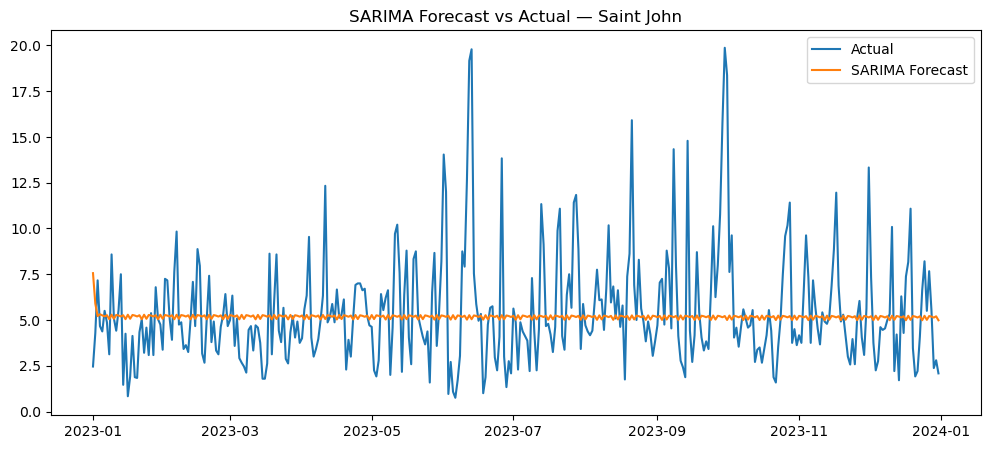

In [16]:
example_city = sarima_results_df.iloc[0]["City"]
y_test_plot, y_pred_plot = forecast_store[example_city]

plt.figure(figsize=(12,5))
plt.plot(y_test_plot.index, y_test_plot.values, label="Actual")
plt.plot(y_pred_plot.index, y_pred_plot.values, label="SARIMA Forecast")
plt.title(f"SARIMA Forecast vs Actual — {example_city}")
plt.legend()
plt.show()

In [17]:
sarima_results_df.to_csv("../results/PM25_SARIMA_results.csv", index=False)
print("Saved: ../results/PM25_SARIMA_results.csv")

Saved: ../results/PM25_SARIMA_results.csv


In [18]:
import pandas as pd

all_forecasts = []

for city, (y_test_city, forecast_city) in forecast_store.items():
    city_df = pd.DataFrame({
        "Date": y_test_city.index,
        "City": city,
        "Actual_PM25": y_test_city.values,
        "Forecast_PM25": forecast_city
    })
    all_forecasts.append(city_df)

forecast_output = pd.concat(all_forecasts, ignore_index=True)

forecast_output.to_csv("../results/PM25_SARIMA_forecast_daily.csv", index=False)
print("Saved: ../results/PM25_SARIMA_forecast_daily.csv")

forecast_output.head()

Saved: ../results/PM25_SARIMA_forecast_daily.csv


,Date,City,Actual_PM25,Forecast_PM25
0,2023-01-01,Montréal,3.791667,7.617046
1,2023-01-02,Montréal,8.791667,7.076527
2,2023-01-03,Montréal,10.166667,7.060252
3,2023-01-04,Montréal,5.208333,6.638644
4,2023-01-05,Montréal,7.875000,7.349447
